<a href="https://colab.research.google.com/github/elisecolin/Tutorials_Notebooks/blob/main/SimulationSAR_RMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SAR raw signal synthesis and range–azimuth reconstruction

This notebook implements a compact SAR simulation chain. It first synthesizes the complex baseband raw signal generated by isotropic point scatterers, then reconstructs a range–azimuth image with an omega–k / Range Migration Algorithm (RMA) based on Stolt interpolation.

The current model is intentionally simple: each target is an isotropic, frequency-independent point scatterer with a constant complex reflectivity $\rho_p$. This gives a controlled baseline before introducing anisotropic or frequency-dependent scatterers.

The processing chain is

$$
(x_p,y_p,\rho_p)
\longrightarrow
s(t,u)
\longrightarrow
S(f,u)
\longrightarrow
S(f,k_y)
\longrightarrow
F(k_x,k_y)
\longrightarrow
f(x,y).
$$

Here $t$ is fast time, $u$ is the synthetic aperture coordinate, $x$ is range relative to the scene center, and $y$ is azimuth / cross-range.


## 1. Imports and utilities


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Optional
from scipy.interpolate import interp1d


def next_even_integer(x: float) -> int:
    """
    Return the smallest even integer greater than or equal to x.
    """
    n = int(np.ceil(x))
    return n if n % 2 == 0 else n + 1


## 2. SAR acquisition parameters

The notebook does not model a real antenna beam pattern. The aperture is purely synthetic. It can be fixed directly with `synthetic_aperture_length`, or indirectly through a target azimuth resolution.

The transmitted waveform is a linear chirp centered at carrier frequency \(f_c\) and spanning a total bandwidth \(B\). The range resolution is approximately

$$
\Delta x \approx \frac{c}{2B}.
$$

For $B=150\,\mathrm{MHz}$, this gives about $1\,\mathrm{m}$. The synthetic aperture length associated with a desired azimuth resolution is approximated by

$$
L_\mathrm{sa} \approx \frac{\lambda_c X_c}{2\Delta y}.
$$


In [2]:
@dataclass
class SARParams:
    """
    Physical and numerical parameters for a simplified monostatic SAR simulation.

    Geometry
    --------
    The radar moves along the azimuth coordinate u. The scene center is located
    at range Xc. A scatterer has relative coordinates (x, y), and its absolute
    range is X = Xc + x.

    Signal
    ------
    The emitted signal is represented as a complex baseband linear chirp centered
    at fc and spanning the total bandwidth B.
    """

    c: float = 3e8

    fc: float = 9.6e9
    B: float = 150e6
    Tp: float = 5e-6

    Xc: float = 3_000.0
    X0: float = 100.0
    Y0: float = 100.0

    azimuth_resolution: float = 1.0
    synthetic_aperture_length: Optional[float] = None

    range_oversampling: float = 2.0
    aperture_oversampling: float = 1.25
    time_guard: float = 0.10

    n: Optional[int] = None
    m: Optional[int] = None
    du: Optional[float] = None

    def build_axes(self) -> dict:
        """
        Build the time, aperture, frequency, and wavenumber grids.
        """
        pi2 = 2.0 * np.pi

        if self.B <= 0:
            raise ValueError("The chirp bandwidth B must be strictly positive.")
        if self.fc <= self.B / 2.0:
            raise ValueError("The carrier frequency fc must be greater than B/2.")

        f_min = self.fc - self.B / 2.0
        f_max = self.fc + self.B / 2.0

        lambda_c = self.c / self.fc
        lambda_min = self.c / f_max
        lambda_max = self.c / f_min

        wc = pi2 * self.fc
        k_c = pi2 * self.fc / self.c
        k_min = pi2 * f_min / self.c
        k_max = pi2 * f_max / self.c

        # Baseband chirp:
        # p(tau) = exp(j[-pi B tau + alpha tau^2]), 0 <= tau <= Tp.
        alpha = np.pi * self.B / self.Tp
        w_start = wc - np.pi * self.B

        range_resolution = self.c / (2.0 * self.B)

        if self.synthetic_aperture_length is None:
            Lsa = lambda_c * self.Xc / (2.0 * self.azimuth_resolution)
        else:
            Lsa = float(self.synthetic_aperture_length)

        if Lsa <= 0:
            raise ValueError("The synthetic aperture length must be positive.")

        aperture_half_length = Lsa / 2.0

        # Aperture sampling is set from an approximate maximum azimuth spatial
        # frequency. The oversampling factor adds a safety margin.
        Rmin_scene = self.Xc - self.X0
        if Rmin_scene <= 0:
            raise ValueError("Xc - X0 must remain strictly positive.")

        max_cross_offset = self.Y0 + aperture_half_length
        sin_theta_max = max_cross_offset / np.sqrt(Rmin_scene**2 + max_cross_offset**2)
        ku_max_signal = 2.0 * k_max * sin_theta_max
        du_nyquist = np.pi / ku_max_signal

        du = du_nyquist / self.aperture_oversampling if self.du is None else float(self.du)

        if du <= 0:
            raise ValueError("The aperture sampling step du must be positive.")

        if self.m is None:
            m = next_even_integer(Lsa / du)
        else:
            m = int(self.m)
            if m % 2 != 0:
                raise ValueError("m must be even.")

        Lsa_effective = m * du

        u = (np.arange(m) - m / 2.0) * du
        dku = pi2 / (m * du)
        ku = (np.arange(m) - m / 2.0) * dku

        # Fast-time window. It must cover the full round-trip delay range and
        # the transmitted pulse duration.
        Rmin = self.Xc - self.X0
        Rmax = np.sqrt((self.Xc + self.X0) ** 2 + (self.Y0 + aperture_half_length) ** 2)

        Ts = 2.0 * Rmin / self.c
        Tf = 2.0 * Rmax / self.c + self.Tp

        T = Tf - Ts
        Ts = Ts - self.time_guard * T
        Tf = Tf + self.time_guard * T
        T = Tf - Ts

        fs_fast_time = self.range_oversampling * self.B
        dt = 1.0 / fs_fast_time

        if self.n is None:
            n = next_even_integer(T / dt)
        else:
            n = int(self.n)
            if n % 2 != 0:
                raise ValueError("n must be even.")

        t = Ts + np.arange(n) * dt

        f_base = np.fft.fftshift(np.fft.fftfreq(n, d=dt))
        f = self.fc + f_base
        w = pi2 * f
        k = w / self.c

        Ik = np.where(np.abs(f_base) <= self.B / 2.0)[0]

        return {
            "pi2": pi2,
            "c": self.c,
            "fc": self.fc,
            "B": self.B,
            "Tp": self.Tp,
            "wc": wc,
            "w_start": w_start,
            "alpha": alpha,
            "range_resolution": range_resolution,
            "azimuth_resolution_target": self.azimuth_resolution,
            "f_min": f_min,
            "f_max": f_max,
            "lambda_c": lambda_c,
            "lambda_min": lambda_min,
            "lambda_max": lambda_max,
            "k_c": k_c,
            "k_min": k_min,
            "k_max": k_max,
            "synthetic_aperture_length": Lsa,
            "synthetic_aperture_length_effective": Lsa_effective,
            "aperture_half_length": aperture_half_length,
            "du": du,
            "du_nyquist": du_nyquist,
            "m": m,
            "u": u,
            "dku": dku,
            "ku": ku,
            "ku_max_signal": ku_max_signal,
            "Rmin": Rmin,
            "Rmax": Rmax,
            "Ts": Ts,
            "Tf": Tf,
            "T": T,
            "dt": dt,
            "fs_fast_time": fs_fast_time,
            "n": n,
            "t": t,
            "f_base": f_base,
            "f": f,
            "w": w,
            "k": k,
            "Ik": Ik,
        }


def print_sar_summary(params: SARParams) -> None:
    """
    Print the main physical and numerical quantities of the SAR configuration.
    """
    axes = params.build_axes()

    print("=== Radar ===")
    print(f"Carrier frequency fc          : {axes['fc'] / 1e9:.3f} GHz")
    print(f"Bandwidth B                   : {axes['B'] / 1e6:.3f} MHz")
    print(f"Pulse duration Tp             : {axes['Tp'] * 1e6:.3f} µs")
    print(f"Carrier wavelength lambda_c   : {axes['lambda_c']:.4f} m")
    print()

    print("=== Target resolution ===")
    print(f"Range resolution c/(2B)       : {axes['range_resolution']:.3f} m")
    print(f"Azimuth resolution target     : {axes['azimuth_resolution_target']:.3f} m")
    print()

    print("=== Scene geometry ===")
    print(f"Scene center range Xc         : {params.Xc:.1f} m")
    print(f"Range interval                : [{params.Xc - params.X0:.1f}, {params.Xc + params.X0:.1f}] m")
    print(f"Azimuth interval              : [{-params.Y0:.1f}, {params.Y0:.1f}] m")
    print()

    print("=== Synthetic aperture ===")
    print(f"Target aperture length        : {axes['synthetic_aperture_length']:.3f} m")
    print(f"Effective aperture length     : {axes['synthetic_aperture_length_effective']:.3f} m")
    print()

    print("=== Aperture sampling ===")
    print(f"Approximate Nyquist du        : {axes['du_nyquist']:.4f} m")
    print(f"Used du                       : {axes['du']:.4f} m")
    print(f"Number of aperture samples m  : {axes['m']}")
    print(f"Spectral step dku             : {axes['dku']:.4f} rad/m")
    print()

    print("=== Fast-time sampling ===")
    print(f"Fast-time step dt             : {axes['dt'] * 1e9:.3f} ns")
    print(f"Fast-time sampling frequency  : {axes['fs_fast_time'] / 1e6:.3f} MHz")
    print(f"Number of fast-time samples n : {axes['n']}")
    print(f"Fast-time window T            : {axes['T'] * 1e6:.3f} µs")
    print(f"Useful chirp frequency bins   : {len(axes['Ik'])} / {axes['n']}")


params = SARParams(
    fc=9.6e9,
    B=150e6,
    Tp=5e-6,
    Xc=3000.0,
    X0=100.0,
    Y0=100.0,
    azimuth_resolution=1.0,
)

print_sar_summary(params)


=== Radar ===
Carrier frequency fc          : 9.600 GHz
Bandwidth B                   : 150.000 MHz
Pulse duration Tp             : 5.000 µs
Carrier wavelength lambda_c   : 0.0312 m

=== Target resolution ===
Range resolution c/(2B)       : 1.000 m
Azimuth resolution target     : 1.000 m

=== Scene geometry ===
Scene center range Xc         : 3000.0 m
Range interval                : [2900.0, 3100.0] m
Azimuth interval              : [-100.0, 100.0] m

=== Synthetic aperture ===
Target aperture length        : 46.875 m
Effective aperture length     : 46.957 m

=== Aperture sampling ===
Approximate Nyquist du        : 0.1823 m
Used du                       : 0.1458 m
Number of aperture samples m  : 322
Spectral step dku             : 0.1338 rad/m

=== Fast-time sampling ===
Fast-time step dt             : 3.333 ns
Fast-time sampling frequency  : 300.000 MHz
Number of fast-time samples n : 2286
Fast-time window T            : 7.620 µs
Useful chirp frequency bins   : 1143 / 2286


## 3. Isotropic point-scatterer scene

Each scatterer is represented by a triplet $(x_p,y_p,\rho_p)$. The coordinate $x_p$ is relative to the scene center, so the absolute range is $X_c+x_p$. The complex number $\rho_p$ is the coherent reflectivity.

This sparse model is the cleanest way to validate the direct model and the reconstruction before moving to extended or anisotropic targets.


In [3]:
x_targets = np.array([0.0])
y_targets = np.array([0.0])
rho_targets = np.array([1.0 + 0j], dtype=np.complex128)


## 4. Raw SAR signal synthesis

For a scatterer located at $(x_p,y_p)$, the distance from the radar to the scatterer at aperture coordinate $u$ is

$$
R_p(u)=\sqrt{(X_c+x_p)^2+(y_p-u)^2}.
$$

The round-trip delay is

$$
\tau_p(u)=\frac{2R_p(u)}{c}.
$$

The local chirp time is $t_d=t-\tau_p(u)$. The complex baseband raw signal is

$$
s(t,u)
=
\sum_p
\rho_p
\exp\left[
j\left(
-\omega_c\tau_p(u)
-\pi B t_d
+\alpha t_d^2
\right)
\right]
\mathbf{1}_{0\leq t_d\leq T_p},
$$

with $\alpha=\pi B/T_p$. The term $\exp[-j\omega_c\tau_p(u)]$ carries the carrier phase variation along the aperture.


In [4]:
def synthesize_raw_sar_signal(
    x_targets,
    y_targets,
    rho_targets,
    params: SARParams,
    batch_size: int = 32,
    dtype=np.complex128,
    include_range_attenuation: bool = False,
):
    """
    Synthesize the complex baseband raw SAR signal for isotropic point scatterers.
    """
    axes = params.build_axes()

    c = axes["c"]
    wc = axes["wc"]
    B = axes["B"]
    alpha = axes["alpha"]
    Tp = axes["Tp"]

    Xc = params.Xc

    t = axes["t"]
    u = axes["u"]

    n = axes["n"]
    m = axes["m"]

    x_targets = np.asarray(x_targets, dtype=float)
    y_targets = np.asarray(y_targets, dtype=float)
    rho_targets = np.asarray(rho_targets, dtype=dtype)

    if not (len(x_targets) == len(y_targets) == len(rho_targets)):
        raise ValueError("x_targets, y_targets and rho_targets must have the same length.")

    if np.any(np.abs(x_targets) > params.X0):
        print("Warning: at least one target is outside the nominal range scene extent.")
    if np.any(np.abs(y_targets) > params.Y0):
        print("Warning: at least one target is outside the nominal azimuth scene extent.")

    s = np.zeros((n, m), dtype=dtype)

    n_targets = len(rho_targets)

    for start in range(0, n_targets, batch_size):
        stop = min(start + batch_size, n_targets)

        xb = x_targets[start:stop]
        yb = y_targets[start:stop]
        rb = rho_targets[start:stop]

        # Distance from radar to each target for each aperture position.
        R = np.sqrt((Xc + xb[:, None]) ** 2 + (yb[:, None] - u[None, :]) ** 2)

        # Round-trip delay.
        tau = 2.0 * R / c

        # Local time inside the chirp.
        td = t[:, None, None] - tau[None, :, :]

        # Rectangular support of the transmitted pulse.
        gate = (td >= 0.0) & (td <= Tp)

        phase = (
            -wc * tau[None, :, :]
            -np.pi * B * td
            +alpha * td**2
        )

        echo = np.exp(1j * phase) * gate

        if include_range_attenuation:
            echo = echo / (R[None, :, :] ** 2)

        # Coherent summation over the scatterers in the current batch.
        s += np.sum(rb[None, :, None] * echo, axis=1).astype(dtype)

    return s


s = synthesize_raw_sar_signal(
    x_targets,
    y_targets,
    rho_targets,
    params,
    batch_size=1,
    include_range_attenuation=False,
)


### Raw-signal visualization

With the X-band parameters used here, the magnitude of the raw signal may look like a broad rectangular pulse. This is expected: the SAR information is mainly in the phase variation along the aperture, not in the magnitude alone.


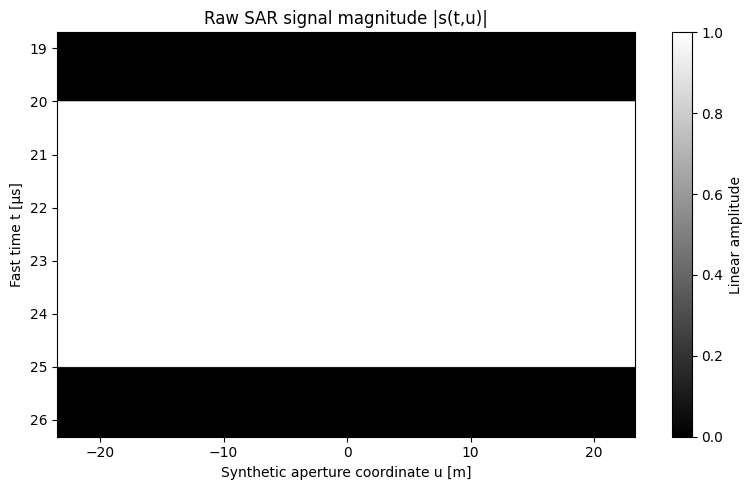

In [5]:
def plot_raw_signal_magnitude(s, params: SARParams, vmax=None) -> None:
    """
    Plot the raw SAR signal magnitude in the fast-time/aperture domain.
    """
    axes = params.build_axes()
    t = axes["t"]
    u = axes["u"]

    amplitude = np.abs(s)
    if vmax is None:
        vmax = np.max(amplitude)

    plt.figure(figsize=(8, 5))
    plt.imshow(
        amplitude,
        extent=[u[0], u[-1], t[-1] * 1e6, t[0] * 1e6],
        aspect="auto",
        cmap="gray",
        vmin=0,
        vmax=vmax,
    )
    plt.xlabel("Synthetic aperture coordinate u [m]")
    plt.ylabel("Fast time t [µs]")
    plt.title("Raw SAR signal magnitude |s(t,u)|")
    plt.colorbar(label="Linear amplitude")
    plt.tight_layout()
    plt.show()


plot_raw_signal_magnitude(s, params)


## 5. Range filtering

The fast-time reference chirp is generated for a point target located at the scene center. Two range filters are implemented:

- `matched`: the classical matched filter \(S_\mathrm{raw}S_0^\ast\);
- `whitened`: a normalized matched filter \(S_\mathrm{raw}S_0^\ast/(|S_0|^2+\epsilon)\), useful for noiseless synthetic tests because it reduces the chirp spectral envelope.


In [6]:
def make_fast_time_reference(params: SARParams, x_ref: float = 0.0):
    """
    Build the fast-time reference chirp used for range filtering.
    """
    axes = params.build_axes()

    c = axes["c"]
    wc = axes["wc"]
    B = axes["B"]
    alpha = axes["alpha"]
    Tp = axes["Tp"]
    t = axes["t"]

    X_ref = params.Xc + x_ref
    tau0 = 2.0 * X_ref / c
    td0 = t - tau0

    gate = (td0 >= 0.0) & (td0 <= Tp)

    phase = (
        -wc * tau0
        -np.pi * B * td0
        +alpha * td0**2
    )

    return np.exp(1j * phase) * gate


def fft_fast_time(x):
    """
    FFT along fast time with a centered output frequency grid.
    """
    return np.fft.fftshift(np.fft.fft(x, axis=0), axes=0)


def ifft_fast_time(X):
    """
    Inverse transform associated with fft_fast_time().
    """
    return np.fft.ifft(np.fft.ifftshift(X, axes=0), axis=0)


def range_filter(
    s_raw,
    params: SARParams,
    x_ref: float = 0.0,
    mode: str = "whitened",
    eps: float = 1e-6,
):
    """
    Apply fast-time range filtering and keep only the useful chirp band.
    """
    axes = params.build_axes()
    Ik = axes["Ik"]

    s0 = make_fast_time_reference(params, x_ref=x_ref)

    S_raw = fft_fast_time(s_raw)
    S0 = fft_fast_time(s0)

    if mode == "matched":
        H = np.conj(S0)
    elif mode == "whitened":
        power = np.abs(S0) ** 2
        H = np.conj(S0) / (power + eps * np.max(power))
    else:
        raise ValueError("mode must be either 'matched' or 'whitened'.")

    S_range = S_raw * H[:, None]
    S_range = S_range[Ik, :]

    return S_range, s0, S0, H


## 6. Fourier utilities and zero padding

The aperture axis \(u\) is centered around zero, so aperture FFTs use `ifftshift` before the FFT and `fftshift` after it.

Zero padding along \(k_x\) is used only to sample the reconstructed range profile more finely. It does not change the physical resolution.


In [7]:
def fft_aperture(u_signal):
    """
    FFT along the centered synthetic aperture coordinate u.
    """
    return np.fft.fftshift(
        np.fft.fft(
            np.fft.ifftshift(u_signal, axes=1),
            axis=1
        ),
        axes=1
    )


def fft_aperture_padded(u_signal, m_fft: int):
    """
    FFT along aperture with centered zero padding.
    """
    nk, m = u_signal.shape

    if m_fft < m:
        raise ValueError("m_fft must be greater than or equal to the number of aperture samples.")
    if m_fft % 2 != 0:
        raise ValueError("m_fft must be even.")

    padded = np.zeros((nk, m_fft), dtype=u_signal.dtype)
    start = (m_fft - m) // 2
    padded[:, start:start + m] = u_signal

    return np.fft.fftshift(
        np.fft.fft(
            np.fft.ifftshift(padded, axes=1),
            axis=1
        ),
        axes=1
    )


def ifft2_centered(F):
    """
    2D inverse FFT of a spectrum centered in both dimensions.
    """
    return np.fft.fftshift(
        np.fft.ifft2(
            np.fft.ifftshift(F, axes=(0, 1)),
            axes=(0, 1)
        ),
        axes=(0, 1)
    )


def zero_pad_kx(F, pad_factor: int = 1):
    """
    Centered zero padding along the kx dimension.
    """
    if pad_factor == 1:
        return F
    if pad_factor < 1:
        raise ValueError("pad_factor must be greater than or equal to 1.")

    nx, ny = F.shape
    nx_pad = int(pad_factor * nx)
    if nx_pad % 2 != 0:
        nx_pad += 1

    F_pad = np.zeros((nx_pad, ny), dtype=F.dtype)
    start = (nx_pad - nx) // 2
    F_pad[start:start + nx, :] = F

    return F_pad


## 7. Omega–k reconstruction with Stolt interpolation

After range filtering, the signal is transformed from aperture coordinate $u$ to azimuth spatial frequency $k_y$. The monostatic SAR dispersion relation is

$$
k_x = \sqrt{4k^2-k_y^2},
$$

where $k=2\pi f/c$ is the RF wavenumber.

The data are not uniformly sampled in $k_x$. Stolt interpolation resamples them onto a uniform Cartesian grid $F(k_x,k_y)$, after which a centered 2D inverse FFT gives the range–azimuth image.


In [8]:
def reconstruct_sar_range_azimuth(
    s_raw,
    params: SARParams,
    interpolation_kind: str = "linear",
    x_ref: float = 0.0,
    window: Optional[str] = None,
    use_stolt_jacobian: bool = False,
    range_filter_mode: str = "whitened",
    range_zeropad: int = 8,
    y_output_extent: Optional[float] = None,
):
    """
    Reconstruct a SAR image in range-azimuth coordinates using omega-k processing.
    """
    axes = params.build_axes()

    pi2 = axes["pi2"]
    k = axes["k"]
    Ik = axes["Ik"]

    n = axes["n"]
    m = axes["m"]

    du = axes["du"]
    ku = axes["ku"]
    dku = axes["dku"]

    Xc = params.Xc
    X0 = params.X0

    s_raw = np.asarray(s_raw, dtype=np.complex128)

    if s_raw.shape != (n, m):
        raise ValueError(f"s_raw has shape {s_raw.shape}, but expected shape is {(n, m)}.")

    # Step 1: range filtering in fast-time frequency.
    S_range, s0, S0, H_range = range_filter(
        s_raw,
        params,
        x_ref=x_ref,
        mode=range_filter_mode,
    )

    k_valid = k[Ik]

    # Step 2: aperture FFT, optionally with zero padding to enlarge the y display extent.
    if y_output_extent is None:
        S_ky = fft_aperture(S_range)
        ky = ku.copy()
        dky = dku
        ny = len(ky)
    else:
        m_fft_az = next_even_integer(y_output_extent / du)
        m_fft_az = max(m_fft_az, m)

        S_ky = fft_aperture_padded(S_range, m_fft=m_fft_az)

        ny = m_fft_az
        dky = pi2 / (ny * du)
        ky = (np.arange(ny) - ny / 2.0) * dky

    dy = pi2 / (ny * dky)
    azimuth_axis = (np.arange(ny) - ny / 2.0) * dy

    # Step 3: dispersion relation.
    kx_squared = 4.0 * k_valid[:, None] ** 2 - ky[None, :] ** 2
    valid_kx = kx_squared > 0.0

    kx = np.zeros_like(kx_squared)
    kx[valid_kx] = np.sqrt(kx_squared[valid_kx])

    # Step 4: phase compensation inherited from the standard RMA formulation.
    phase_filter = (
        kx * Xc
        + np.pi / 4.0
        - 2.0 * k_valid[:, None] * Xc
    )

    H_2d = np.exp(1j * phase_filter)
    H_2d *= valid_kx

    S_matched = S_ky * H_2d

    if use_stolt_jacobian:
        k_grid = np.repeat(k_valid[:, None], ny, axis=1)
        jacobian = np.zeros_like(kx)
        jacobian[valid_kx] = kx[valid_kx] / (4.0 * k_grid[valid_kx])
        S_matched *= jacobian

    # Step 5: Stolt interpolation to a uniform kx grid.
    kx_positive = kx[valid_kx]
    kx_min = np.min(kx_positive)
    kx_max = np.max(kx_positive)

    dkx = np.pi / X0

    nx = int(np.floor((kx_max - kx_min) / dkx)) + 1
    nx = nx if nx % 2 == 0 else nx + 1

    KX = kx_min + np.arange(nx) * dkx

    F = np.zeros((nx, ny), dtype=np.complex128)

    for j in range(ny):
        valid = valid_kx[:, j]

        if np.count_nonzero(valid) < 4:
            continue

        kx_j = kx[valid, j]
        S_j = S_matched[valid, j]

        order = np.argsort(kx_j)
        kx_j = kx_j[order]
        S_j = S_j[order]

        kx_unique, unique_idx = np.unique(kx_j, return_index=True)
        S_unique = S_j[unique_idx]

        if len(kx_unique) < 4:
            continue

        interp_real = interp1d(
            kx_unique,
            np.real(S_unique),
            kind=interpolation_kind,
            bounds_error=False,
            fill_value=0.0,
            assume_sorted=True,
        )

        interp_imag = interp1d(
            kx_unique,
            np.imag(S_unique),
            kind=interpolation_kind,
            bounds_error=False,
            fill_value=0.0,
            assume_sorted=True,
        )

        F[:, j] = interp_real(KX) + 1j * interp_imag(KX)

    # Step 6: optional spectral window.
    if window is not None:
        if window == "hann":
            wx = np.hanning(nx)
            wy = np.hanning(ny)
        elif window == "hamming":
            wx = np.hamming(nx)
            wy = np.hamming(ny)
        else:
            raise ValueError("window must be None, 'hann' or 'hamming'.")

        F = F * wx[:, None] * wy[None, :]

    # Step 7: range zero padding and final 2D inverse FFT.
    F_ifft = zero_pad_kx(F, pad_factor=range_zeropad)
    nx_ifft = F_ifft.shape[0]

    f_xy = ifft2_centered(F_ifft)

    dx = pi2 / (nx_ifft * dkx)
    x_relative = (np.arange(nx_ifft) - nx_ifft / 2.0) * dx
    range_axis = Xc + x_relative

    # f_xy is indexed as f[x, y]. Transpose for image display as f[y, x].
    image_complex = f_xy.T
    image = np.abs(image_complex)

    debug = {
        "s0": s0,
        "S0": S0,
        "H_range": H_range,
        "S_range": S_range,
        "S_ky": S_ky,
        "k_valid": k_valid,
        "ky": ky,
        "kx": kx,
        "valid_kx": valid_kx,
        "H_2d": H_2d,
        "S_matched": S_matched,
        "KX": KX,
        "F_before_padding": F,
        "F_ifft": F_ifft,
        "f_xy": f_xy,
        "image_complex": image_complex,
        "dx": dx,
        "dy": dy,
        "dkx": dkx,
        "dky": dky,
        "range_filter_mode": range_filter_mode,
        "range_zeropad": range_zeropad,
        "range_axis": range_axis,
        "azimuth_axis": azimuth_axis,
    }

    return image, range_axis, azimuth_axis, debug


image, range_axis, azimuth_axis, debug = reconstruct_sar_range_azimuth(
    s,
    params,
    interpolation_kind="linear",
    window=None,
    use_stolt_jacobian=False,
    range_filter_mode="whitened",
    range_zeropad=8,
    y_output_extent=2.0 * params.Y0,
)

iy, ix = np.unravel_index(np.argmax(image), image.shape)

print("Reconstructed maximum:")
print(f"X = {range_axis[ix]:.3f} m")
print(f"Y = {azimuth_axis[iy]:.3f} m")
print(f"Amplitude = {image[iy, ix]:.6e}")


Reconstructed maximum:
X = 3000.000 m
Y = 0.000 m
Amplitude = 7.791302e-01


## 8. Range–azimuth visualization

The image is displayed on a normalized linear amplitude scale. Lowering `vmax` simply saturates the strongest pixel values to reveal sidelobes; it does not modify the reconstructed data.


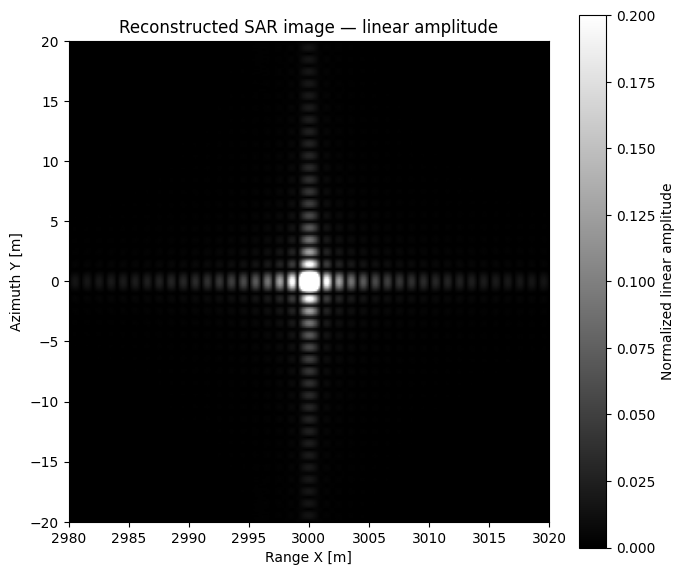

In [9]:
def plot_reconstructed_linear(
    image,
    range_axis,
    azimuth_axis,
    params: Optional[SARParams] = None,
    vmax: float = 1.0,
    y_lim=None,
    x_lim=None,
    title: str = "Reconstructed SAR image — linear amplitude",
):
    """
    Plot a reconstructed SAR image using normalized linear amplitude.
    """
    image_norm = image / (np.max(image) + 1e-15)

    plt.figure(figsize=(7, 6))
    plt.imshow(
        image_norm,
        extent=[
            range_axis[0],
            range_axis[-1],
            azimuth_axis[0],
            azimuth_axis[-1],
        ],
        origin="lower",
        aspect="equal",
        cmap="gray",
        vmin=0,
        vmax=vmax,
    )

    plt.xlabel("Range X [m]")
    plt.ylabel("Azimuth Y [m]")
    plt.title(title)
    plt.colorbar(label="Normalized linear amplitude")

    if x_lim is not None:
        plt.xlim(*x_lim)
    elif params is not None:
        plt.xlim(params.Xc - params.X0, params.Xc + params.X0)

    if y_lim is not None:
        plt.ylim(*y_lim)
    elif params is not None:
        plt.ylim(-params.Y0, params.Y0)

    plt.tight_layout()
    plt.show()


plot_reconstructed_linear(
    image,
    range_axis,
    azimuth_axis,
    params=params,
    vmax=0.2,
    x_lim=(params.Xc - 20, params.Xc + 20),
    y_lim=(-20, 20),
)


## 9. Point-spread function diagnostics

For a single point scatterer, the reconstructed image is the system point-spread function. Profiles through the maximum provide a direct way to inspect the range and azimuth focusing.


=== Reconstructed maximum ===
X max = 3000.000 m
Y max = 0.000 m

=== Full width at half maximum ===
Range FWHM   = 1.207 m
Azimuth FWHM = 1.205 m


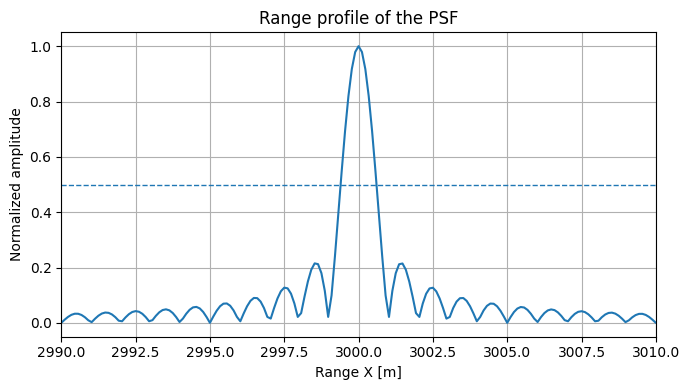

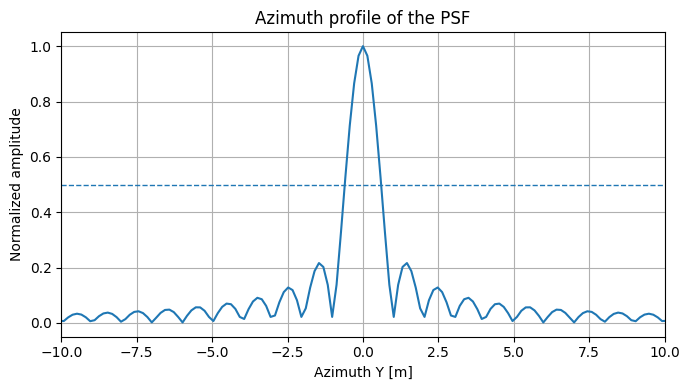

In [10]:
def estimate_fwhm(axis, profile):
    """
    Estimate the full width at half maximum of a positive 1D profile.
    """
    profile = np.asarray(profile, dtype=float)
    profile = profile / (np.max(profile) + 1e-15)

    peak_idx = np.argmax(profile)
    half = 0.5

    left = peak_idx
    while left > 0 and profile[left] >= half:
        left -= 1

    right = peak_idx
    while right < len(profile) - 1 and profile[right] >= half:
        right += 1

    if left == 0 or right == len(profile) - 1:
        return np.nan

    x1, x2 = axis[left], axis[left + 1]
    y1, y2 = profile[left], profile[left + 1]
    x_left = x1 + (half - y1) * (x2 - x1) / (y2 - y1 + 1e-15)

    x1, x2 = axis[right - 1], axis[right]
    y1, y2 = profile[right - 1], profile[right]
    x_right = x1 + (half - y1) * (x2 - x1) / (y2 - y1 + 1e-15)

    return x_right - x_left


def analyze_point_spread_function(image, range_axis, azimuth_axis):
    """
    Extract range and azimuth profiles through the reconstructed maximum.
    """
    image = np.abs(image)
    image = image / (np.max(image) + 1e-15)

    iy, ix = np.unravel_index(np.argmax(image), image.shape)

    range_profile = image[iy, :]
    azimuth_profile = image[:, ix]

    fwhm_range = estimate_fwhm(range_axis, range_profile)
    fwhm_azimuth = estimate_fwhm(azimuth_axis, azimuth_profile)

    print("=== Reconstructed maximum ===")
    print(f"X max = {range_axis[ix]:.3f} m")
    print(f"Y max = {azimuth_axis[iy]:.3f} m")
    print()
    print("=== Full width at half maximum ===")
    print(f"Range FWHM   = {fwhm_range:.3f} m")
    print(f"Azimuth FWHM = {fwhm_azimuth:.3f} m")

    return {
        "ix": ix,
        "iy": iy,
        "range_profile": range_profile,
        "azimuth_profile": azimuth_profile,
        "fwhm_range": fwhm_range,
        "fwhm_azimuth": fwhm_azimuth,
    }


def plot_psf_profiles(psf, range_axis, azimuth_axis, params: Optional[SARParams] = None):
    """
    Plot range and azimuth profiles through the PSF maximum.
    """
    range_profile = psf["range_profile"]
    azimuth_profile = psf["azimuth_profile"]

    plt.figure(figsize=(7, 4))
    plt.plot(range_axis, range_profile)
    plt.axhline(0.5, linestyle="--", linewidth=1)
    if params is not None:
        plt.xlim(params.Xc - 10, params.Xc + 10)
    plt.xlabel("Range X [m]")
    plt.ylabel("Normalized amplitude")
    plt.title("Range profile of the PSF")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(azimuth_axis, azimuth_profile)
    plt.axhline(0.5, linestyle="--", linewidth=1)
    plt.xlim(-10, 10)
    plt.xlabel("Azimuth Y [m]")
    plt.ylabel("Normalized amplitude")
    plt.title("Azimuth profile of the PSF")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


psf = analyze_point_spread_function(image, range_axis, azimuth_axis)
plot_psf_profiles(psf, range_axis, azimuth_axis, params=params)


## 10. Multi-scatterer example

Once the single-point PSF is validated, the same pipeline can be applied to several isotropic point scatterers. Later, the direct model can be generalized by replacing each scalar \(\rho_p\) with an angle- and frequency-dependent scattering response \(\rho_p(f,u)\).


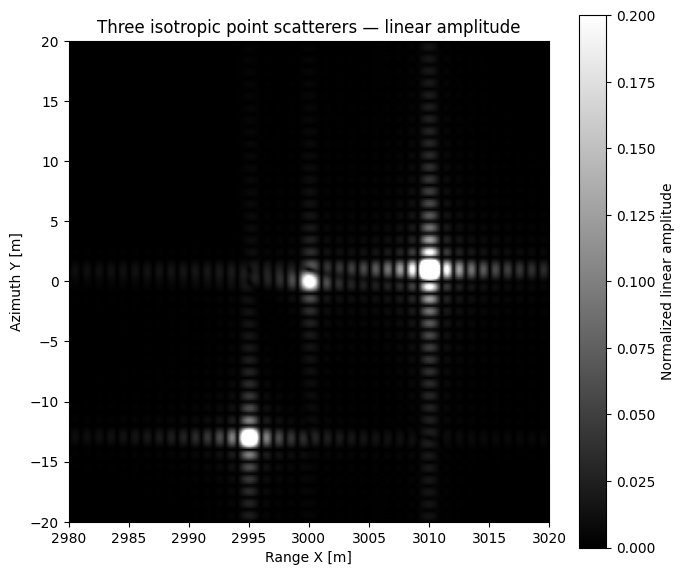

In [11]:
x_targets_multi = np.array([0.0, 10.0, -5.0])
y_targets_multi = np.array([0.0, 1.0, -13.0])
rho_targets_multi = np.array([1.0 + 0j, 2.0 + 3j, 1.2 + 1.2j], dtype=np.complex128)

s_multi = synthesize_raw_sar_signal(
    x_targets_multi,
    y_targets_multi,
    rho_targets_multi,
    params,
    batch_size=3,
    include_range_attenuation=False,
)

image_multi, range_axis_multi, azimuth_axis_multi, debug_multi = reconstruct_sar_range_azimuth(
    s_multi,
    params,
    interpolation_kind="linear",
    window=None,
    use_stolt_jacobian=False,
    range_filter_mode="whitened",
    range_zeropad=8,
    y_output_extent=2.0 * params.Y0,
)

plot_reconstructed_linear(
    image_multi,
    range_axis_multi,
    azimuth_axis_multi,
    params=params,
    vmax=0.2,
    x_lim=(params.Xc - 20, params.Xc + 20),
    y_lim=(-20, 20),
    title="Three isotropic point scatterers — linear amplitude",
)
